In [1]:
!pip install -q scikit-learn tensorflow pandas numpy matplotlib tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, ConfusionMatrixDisplay, roc_curve, auc
)

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

import joblib
import json
import os

In [2]:
train = pd.read_csv('/content/Train_data.csv')
test = pd.read_csv('/content/Test_data.csv')

print("\nTrain head:")
display(train.head())

print("Dataset loaded correctly.")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train head:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


Dataset loaded correctly.
Train shape: (25192, 42)
Test shape: (22544, 41)


In [3]:
# Encoding
for col in ['protocol_type', 'service', 'flag', 'class']:
    train[col] = train[col].astype('category').cat.codes

print("\nEncoding completed. Column types:")
print(train.dtypes)

# Separate features and target
array = train.values
X = array[:, 0:41]
y = np.array([(1 - x) for x in array[:, 41]]).astype(int)

print("\nUnique values of y:", np.unique(y))


# Standardization
scaler_path = "scaler.joblib"

if os.path.exists(scaler_path):
  print("Scaler already exists, loading it...")
  scaler = StandardScaler().fit(X)
  X_scaled = scaler.transform(X)

else:
  print("Scaler not found, creating and saving it...")
  scaler = StandardScaler().fit(X)
  X_scaled = scaler.transform(X)
  joblib.dump(scaler, scaler_path)
  print("Scaler saved.")


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42
)

print("\nTrain/test split completed.")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

# Final checks

print("\nMean of scaled features (rounded):")
print(np.round(X_scaled.mean(axis=0), 2))

print("\nStd of scaled features (rounded):")
print(np.round(X_scaled.std(axis=0), 2))


Encoding completed. Column types:
duration                         int64
protocol_type                     int8
service                           int8
flag                              int8
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                  

In [4]:
print("Sample of encoded categorical columns:")
print(train[['protocol_type','service','flag','class']].head())



Sample of encoded categorical columns:
   protocol_type  service  flag  class
0              1       19     9      1
1              2       41     9      1
2              1       46     5      0
3              1       22     9      1
4              1       22     9      1


In [5]:
# Logistic Regression Model
logreg_path = "logreg_model.joblib"

if os.path.exists(logreg_path):
    print("Loading saved Logistic Regression model...")
    clf_log = joblib.load(logreg_path)

    # Printing the saved best solver…
    print("Best solver LR :", clf_log.best_params_["solver"])

else:
    print("Logistic Regression model not found, training it...")

    solver_list = ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
    params = dict(solver=solver_list)

    logreg = LogisticRegression(max_iter=10000)
    clf_log = GridSearchCV(logreg, params, cv=5, n_jobs=-1)
    clf_log.fit(X_train, y_train)

    # Printing best_solver
    best_solver = clf_log.best_params_["solver"]
    print("Best solver found:", best_solver)

    # Saving model
    joblib.dump(clf_log, logreg_path)


    print("Logistic Regression model saved.")


# === PREDICTIONS ===
y_pred_log = clf_log.predict(X_test)
y_proba_log = clf_log.predict_proba(X_test)



Loading saved Logistic Regression model...
Best solver LR : lbfgs


In [6]:
#K-NN Model
knn_path = "knn_model.joblib"

if os.path.exists(knn_path):
    print("Loading saved KNN model...")
    knn = joblib.load(knn_path)

    # Retrieving best_k from the saved model
    best_k = knn.get_params()["n_neighbors"]
    print("Best k KNN:", best_k)

else:
    print("KNN model not found, training it...")

    errors, losses = [], []
    best_k, best_acc = None, -1

    # Searching for the best k
    for k in range(1, 40):
        temp = KNeighborsClassifier(n_neighbors=k)
        temp.fit(X_train, y_train)
        y_pred = temp.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_k = k

    print(f"Best k found: {best_k} with accuracy {best_acc:.4f}")

    # Training the final model
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train, y_train)

    # Saving model
    joblib.dump(knn, knn_path)

    print("KNN model saved.")


# === PREDICTIONS ===
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)



Loading saved KNN model...
Best k KNN: 2


In [7]:
#SVM Model
svm_path = "svm_model.joblib"
fs_path = "feature_selector.joblib"

if os.path.exists(svm_path) and os.path.exists(fs_path):
    print("Loading saved SVM model and Feature Selector...")

    clf_svm = joblib.load(svm_path)
    fs = joblib.load(fs_path)

    print("Kernel SVM :", clf_svm.kernel)
    print("Feature selection k SVM:", fs.k)

    # Transforming data
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)

else:
    print("SVM model not found, training it...")

    # Feature selection
    fs = SelectKBest(score_func=mutual_info_classif, k=30)
    fs.fit(X_train, y_train)

    # Saving the feature selector
    joblib.dump(fs, fs_path)
    print("Feature Selector saved.")

    # Transforming data
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)

    # Training SVM
    clf_svm = SVC(kernel='rbf', gamma='scale', C=1, probability=True)
    clf_svm.fit(X_train_fs, y_train)

    # Saving model
    joblib.dump(clf_svm, svm_path)

    print("SVM model saved.")
    print("Kernel:", clf_svm.kernel)
    print("Feature selection k:", fs.k)


# === PREDICTIONS ===
y_pred_svm = clf_svm.predict(X_test_fs)
y_proba_svm = clf_svm.predict_proba(X_test_fs)

Loading saved SVM model and Feature Selector...
Kernel SVM : rbf
Feature selection k SVM: 30


In [8]:
# ANN Model
ann_path = "ann_model.keras"

if os.path.exists(ann_path):
    print("Loading saved ANN model...")
    ann = load_model(ann_path)

    print("ANN architecture:")
    ann.summary()

    print("Learning rate:", ann.optimizer.learning_rate.numpy())


else:
    print("ANN model not found, training it...")

    tf.random.set_seed(42)

    n_features = X_train.shape[1]

    # Model architecture
    model = Sequential([
        Dense(32, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    # Training
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )

    # Saving
    model.save(ann_path)

    ann = model

    # Saving parameters
    with open(ann_params_path, "w") as f:
      json.dump({
          "lr": 0.001,
          "batch_size": 64,
          "epochs": 100,
          "architecture": "32-16-1 with BN+Dropout"
      }, f)

    print("ANN model saved.")

    print("ANN architecture:")
    ann.summary()

    print("Learning rate:", ann.optimizer.learning_rate.numpy())

# === PREDICTIONS ===
proba_ann = ann.predict(X_test).ravel()
pred = (proba_ann > 0.5).astype(int)

test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
print(f"ANN Test Loss: {test_loss:.4f}")
print(f"ANN Test Accuracy: {test_acc:.4f}")




Loading saved ANN model...
ANN architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,053 (23.65 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 3,972 (15.52 KB)

Learning rate: 1.5625e-05
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
ANN Test Loss: 0.0298
ANN Test Accuracy: 0.9905


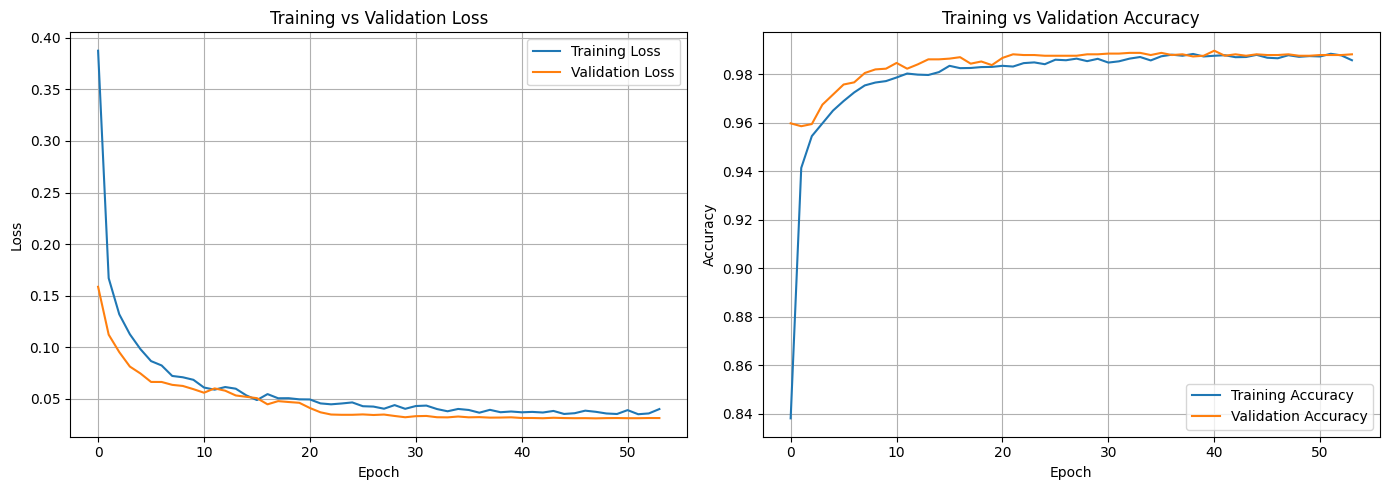

In [ ]:

plt.figure(figsize=(14, 5))

# Subplot 1: Loss

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [9]:
# Decision Tree Model
dt_path = "dt_model.joblib"

if os.path.exists(dt_path):
    print("Loading saved Decision Tree model...")
    dt = joblib.load(dt_path)

    print("DT parameters:", dt.get_params())

else:
    print("Decision Tree model not found, training it...")

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=20,
        random_state=42
    )

    dt.fit(X_train, y_train)

    joblib.dump(dt, dt_path)
    print("Decision Tree model saved.")
    print("DT parameters:", dt.get_params())


# === PREDICTIONS ===
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)

Loading saved Decision Tree model...
DT parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [10]:
# Random Forest Model
rf_path = "rf_model.joblib"

if os.path.exists(rf_path):
    print("Loading saved Random Forest model...")
    rf = joblib.load(rf_path)

    print("RF parameters:", rf.get_params())

else:
    print("Random Forest model not found, training it...")

    rf = RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    joblib.dump(rf, rf_path)
    print("Random Forest model saved.")
    print("RF parameters:", rf.get_params())


# === PREDICTIONS ===
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)


Loading saved Random Forest model...
RF parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [11]:
metrics_dict = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1": f1_score(y_test, y_pred_log),
        "ROC-AUC": roc_auc_score(y_test, y_proba_log[:,1]),
        "Log-loss": log_loss(y_test, y_proba_log)
    },
    "k-NN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1": f1_score(y_test, y_pred_knn),
        "ROC-AUC": roc_auc_score(y_test, y_proba_knn[:,1]),
        "Log-loss": log_loss(y_test, y_proba_knn)
    },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1": f1_score(y_test, y_pred_svm),
        "ROC-AUC": roc_auc_score(y_test, y_proba_svm[:,1]),
        "Log-loss": log_loss(y_test, y_proba_svm)
    },
    "ANN": {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba_ann),
        "Log-loss": log_loss(y_test, proba_ann)
    },
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_proba_dt[:,1]),
        "Log-loss": log_loss(y_test, y_proba_dt)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf[:,1]),
        "Log-loss": log_loss(y_test, y_proba_rf)
    }
}


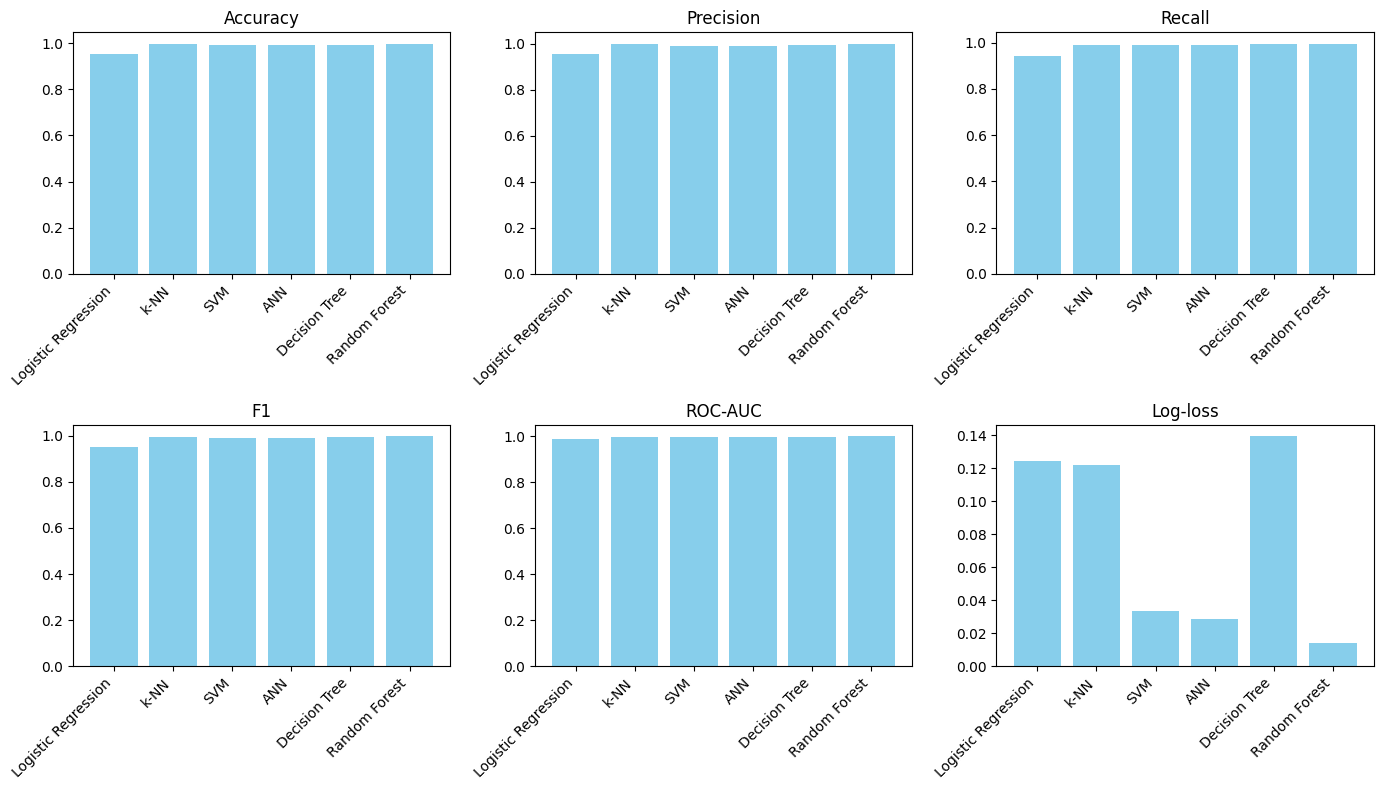

In [12]:
models = list(metrics_dict.keys())
metric_names = list(metrics_dict["Logistic Regression"].keys())

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metric_names):
    plt.subplot(2, 3, i+1)
    values = [metrics_dict[m][metric] for m in models]
    plt.bar(models, values, color='skyblue')
    plt.title(metric)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


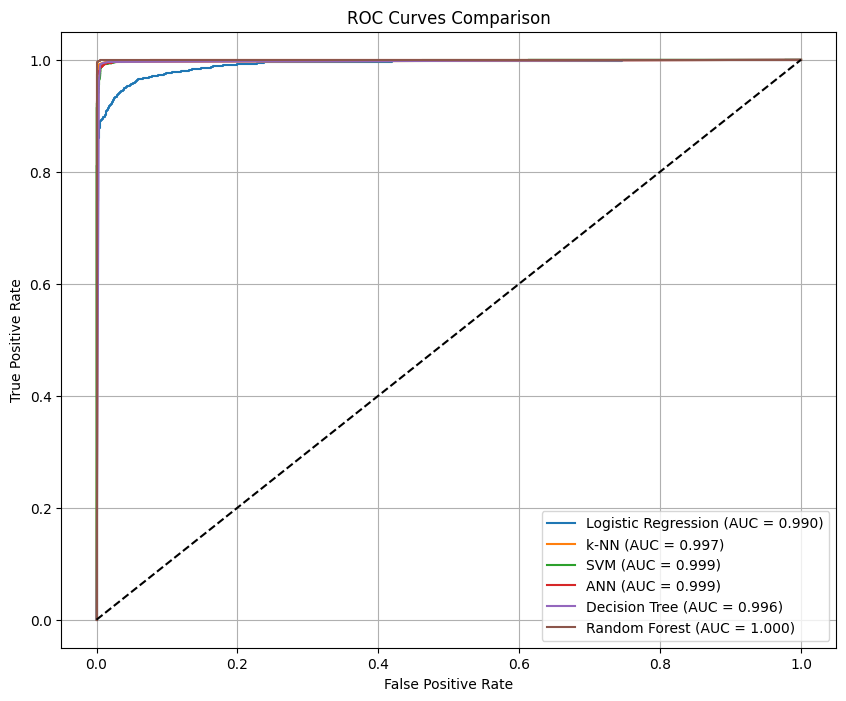

In [13]:
plt.figure(figsize=(10, 8))

def plot_roc(y_test, y_proba, label):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plot_roc(y_test, y_proba_log[:,1], "Logistic Regression")
plot_roc(y_test, y_proba_knn[:,1], "k-NN")
plot_roc(y_test, y_proba_svm[:,1], "SVM")
plot_roc(y_test, proba_ann, "ANN")
plot_roc(y_test, y_proba_dt[:,1], "Decision Tree")
plot_roc(y_test, y_proba_rf[:,1], "Random Forest")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True)
plt.show()


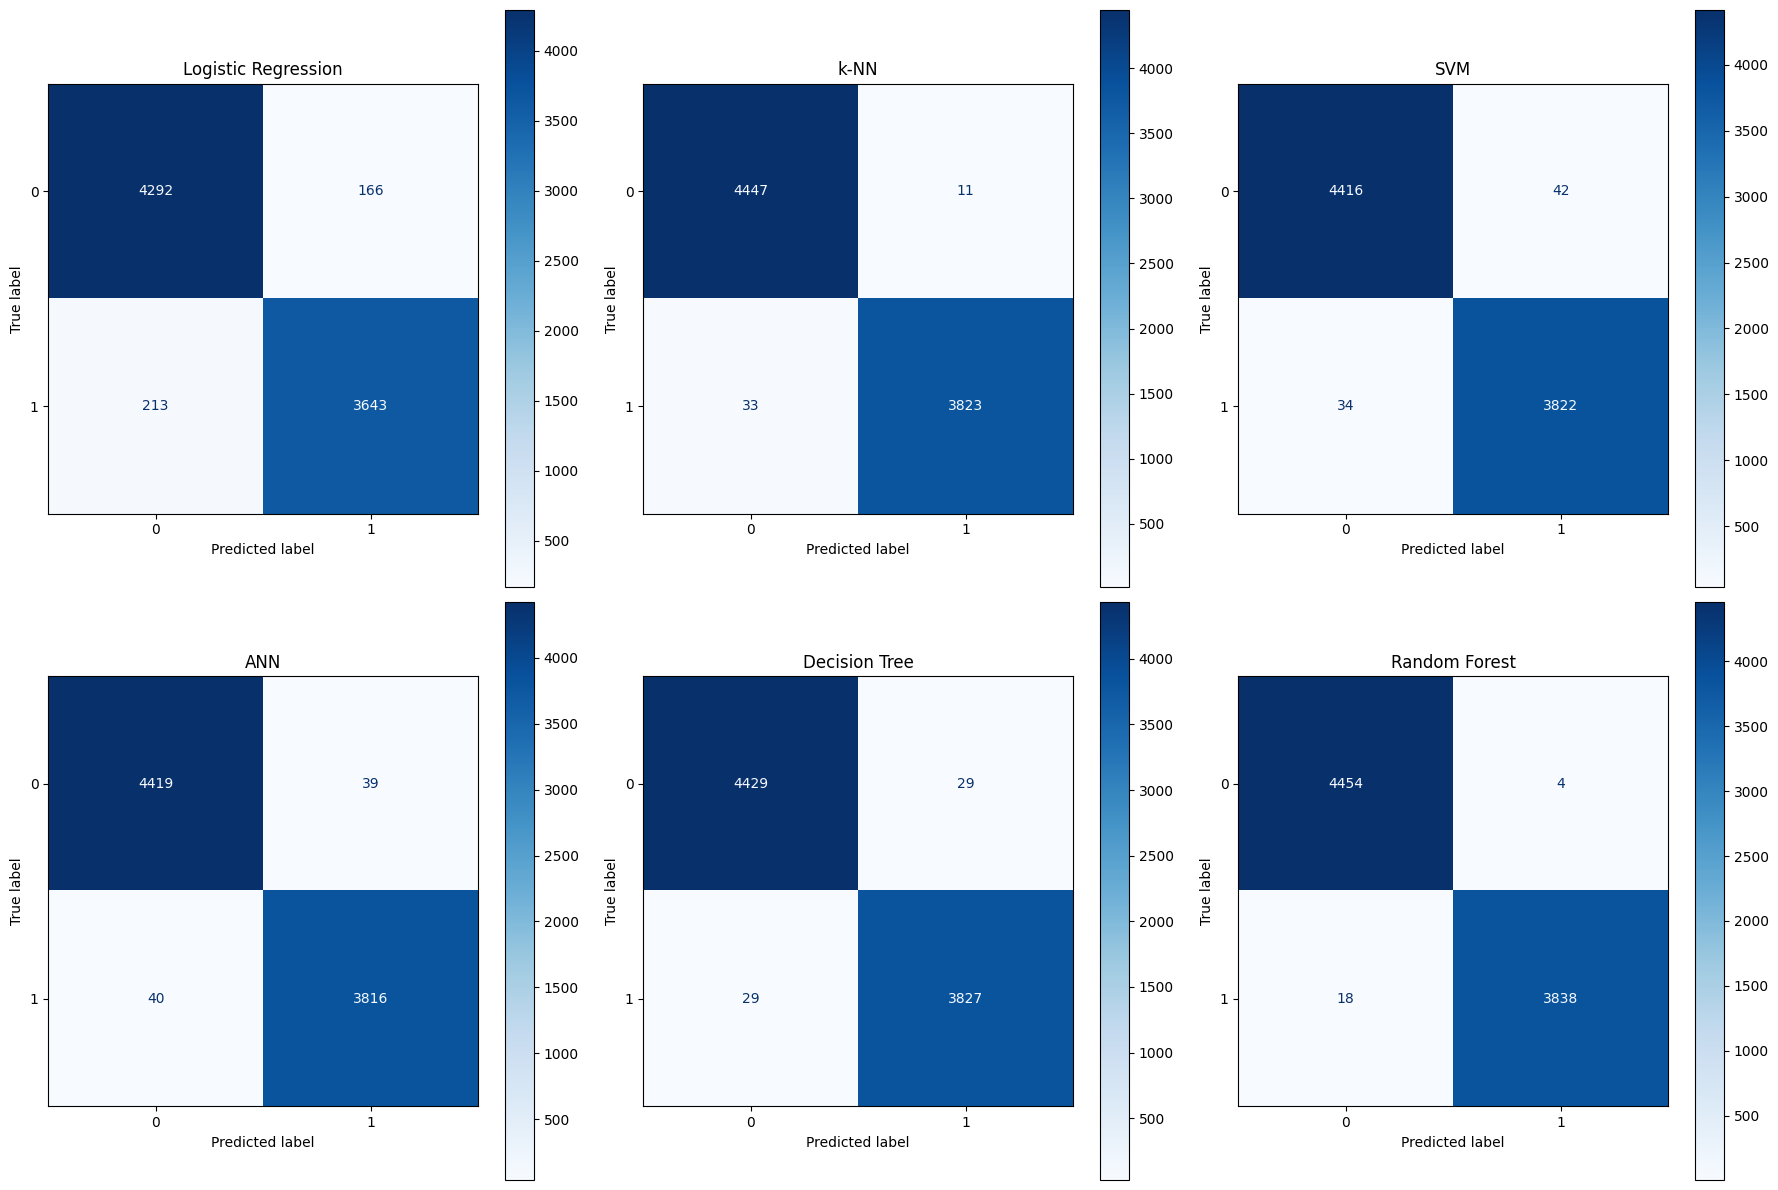

In [14]:
models_preds = {
    "Logistic Regression": y_pred_log,
    "k-NN": y_pred_knn,
    "SVM": y_pred_svm,
    "ANN": pred,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (name, preds) in zip(axes.flatten(), models_preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, cmap='Blues', values_format='d', ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files

files.download("scaler.joblib")
files.download("logreg_model.joblib")
files.download("knn_model.joblib")
files.download("svm_model.joblib")
files.download("feature_selector.joblib")
files.download("ann_model.keras")
files.download("dt_model.joblib")
files.download("rf_model.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
!pip install permetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.7 MB/s eta 0:00:00


In [17]:
# CLUSTERING (K-MEANS) + VALIDITY INDICES
kmeans_path = "kmeans_model.joblib"

from sklearn.cluster import KMeans
from sklearn.metrics import (
    rand_score, jaccard_score, fowlkes_mallows_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from permetrics import ClusteringMetric

if os.path.exists(kmeans_path):
    print("Carico K-Means salvato...")
    kmeans = joblib.load(kmeans_path)
    cluster_labels = kmeans.predict(X_scaled)

else:
    print("Modello K-Means NON trovato, lo alleno...")

    # Fit K-Means with 2 clusters (normal vs attack)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    joblib.dump(kmeans, kmeans_path)
    print("K-Means salvato.")

print("Clustering completed.")


# EXTERNAL VALIDITY METRICS (scikit-learn)

RI  = rand_score(y, cluster_labels)
FMI = fowlkes_mallows_score(y, cluster_labels)
JI  = jaccard_score(y, cluster_labels)

# INTERNAL VALIDITY METRICS (scikit-learn)

SI  = silhouette_score(X_scaled, cluster_labels)
DBI = davies_bouldin_score(X_scaled, cluster_labels)
CHI = calinski_harabasz_score(X_scaled, cluster_labels)

# DUNN INDEX (permetrics)

cm = ClusteringMetric(X=X_scaled, y_pred=cluster_labels)
DI = cm.dunn_index()

print("\n=== External Validity Metrics ===")
print(f"Rand Index (RI): {RI:.6f}")
print(f"Fowlkes-Mallows Index (FMI): {FMI:.6f}")
print(f"Jaccard Index (JI): {JI:.6f}")

print("\n=== Internal Validity Metrics ===")
print(f"Silhouette Index (SI): {SI:.6f}")
print(f"Davies-Bouldin Index (DBI): {DBI:.6f}")
print(f"Calinski-Harabasz Index (CHI): {CHI:.6f}")

print("\n=== Dunn Index ===")
print(f"Dunn Index (DI): {DI:.6f}")



Carico K-Means salvato...
Clustering completed.

=== External Validity Metrics ===
Rand Index (RI): 0.827994
Fowlkes-Mallows Index (FMI): 0.833381
Jaccard Index (JI): 0.798230

=== Internal Validity Metrics ===
Silhouette Index (SI): 0.350746
Davies-Bouldin Index (DBI): 1.438761
Calinski-Harabasz Index (CHI): 5504.372513

=== Dunn Index ===
Dunn Index (DI): 0.022624


In [18]:
# Summary Table of Clustering Metrics

clustering_metrics = {
    "Rand Index (RI)": RI,
    "Fowlkes-Mallows (FMI)": FMI,
    "Jaccard Index (JI)": JI,
    "Silhouette Index (SI)": SI,
    "Davies-Bouldin (DBI)": DBI,
    "Calinski-Harabasz (CHI)": CHI,
    "Dunn Index (DI)": DI
}
print("\n=== Clustering Metrics Summary ===")
display(pd.DataFrame.from_dict(clustering_metrics, orient='index', columns=['Value']))



=== Clustering Metrics Summary ===


,Value
Rand Index (RI),0.827994
Fowlkes-Mallows (FMI),0.833381
Jaccard Index (JI),0.798230
Silhouette Index (SI),0.350746
Davies-Bouldin (DBI),1.438761
Calinski-Harabasz (CHI),5504.372513
Dunn Index (DI),0.022624


In [ ]:
files.download("kmeans_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

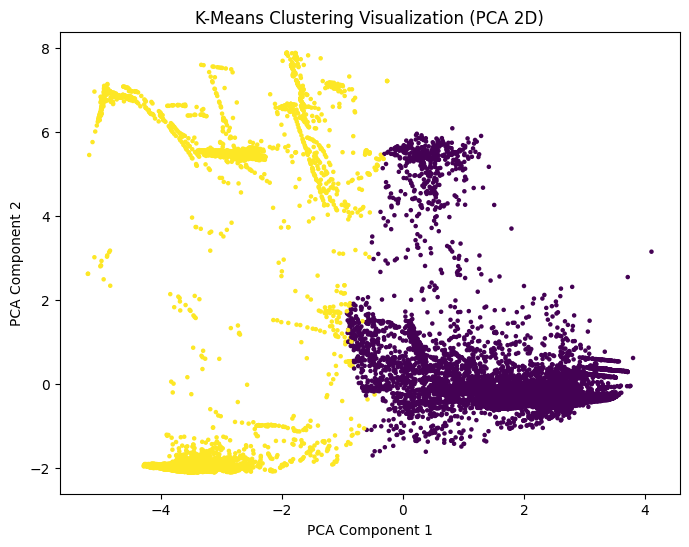

In [19]:
# PCA Visualization of Clusters

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', s=5)
plt.title("K-Means Clustering Visualization (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


The PCA visualization provides an intuitive two‑dimensional representation of the clustering structure, but it captures only a limited portion of the total variance of the original 41‑dimensional dataset.
As a result, the clusters may appear more clearly separated in the PCA plot than they actually are in the full feature space, where quantitative metrics such as the Dunn Index reveal a much higher degree of overlap.


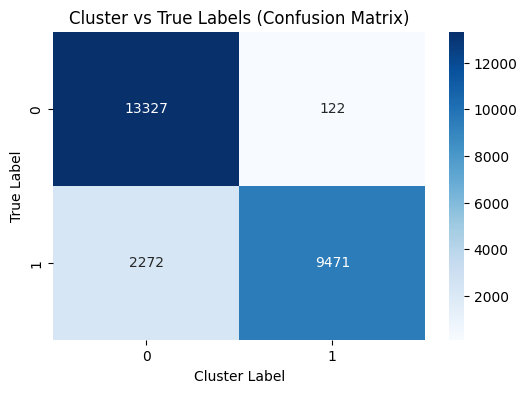

In [20]:
# Heatmap: Cluster vs True Labels

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix between cluster labels and true labels
cm = confusion_matrix(y, cluster_labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Cluster vs True Labels (Confusion Matrix)")
plt.xlabel("Cluster Label")
plt.ylabel("True Label")
plt.show()


The heatmap comparing cluster assignments with the true labels highlights how well the unsupervised K‑Means clusters correspond to the actual classes.
High values along the diagonal indicate that the clustering aligns with the real categories, while off‑diagonal values reveal misclassifications or overlapping regions between normal traffic and attacks.

In [21]:
# NEW CONVERGENCE SECTION
# === train_and_predict functions for each model ===

def tr_logreg(X_train, y_train, X_test):
    clf_log = LogisticRegression(
        solver="lbfgs",
        C=0.3,
        max_iter=10000 )
    clf_log.fit(X_train, y_train)
    return clf_log.predict(X_test)

def tr_knn(X_train, y_train, X_test):
    knn = KNeighborsClassifier(n_neighbors=2)
    knn.fit(X_train, y_train)
    return knn.predict(X_test)

def tr_svm(X_train, y_train, X_test):
    fs = SelectKBest(score_func=mutual_info_classif, k=30)
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    clf_svm = SVC(kernel='rbf', gamma='scale', C=1)
    clf_svm.fit(X_train_fs, y_train)
    return clf_svm.predict(X_test_fs)


def tr_dt(X_train, y_train, X_test):
    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=20,
        random_state=42
    )
    dt.fit(X_train, y_train)
    return dt.predict(X_test)

def tr_rf(X_train, y_train, X_test):
    rf = RandomForestClassifier(
        n_estimators=50,###
        criterion="gini",
        max_depth=10,
        min_samples_split=10,###
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    return rf.predict(X_test)

def tr_ann(X_train, y_train, X_test):

    n_features = X_train.shape[1]

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=1,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )

    proba = model.predict(X_test, verbose=0).ravel()
    return (proba > 0.5).astype(int)

In [22]:
def train_and_eval(model_func, X_train, y_train, X_test, y_test):
    # model_func is directly the function tr_logreg, tr_svm, etc.
    pred = model_func(X_train, y_train, X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")
    return acc, f1

In [23]:
training_sizes = np.linspace(0.1, 1.0, 10)   # 10 values
n_iterations = 100                           # 100 iterations

models = {
    "LogisticRegression": tr_logreg,
    "KNN": tr_knn,
    "SVM": tr_svm,
    "DecisionTree": tr_dt,
    "RandomForest": tr_rf,
    "ANN": tr_ann
}

results_accuracy = {m: {float(s): [] for s in training_sizes} for m in models}
results_f1 = {m: {float(s): [] for s in training_sizes} for m in models}

In [24]:
def get_subsample(X_full, y_full, n_samples):
    if n_samples >= len(X_full):
        return X_full, y_full
    try:
        X_sub, _, y_sub, _ = train_test_split(
            X_full, y_full, train_size=n_samples, stratify=y_full
        )
    except:
        X_sub, _, y_sub, _ = train_test_split(
            X_full, y_full, train_size=n_samples, stratify=None
        )
    return X_sub, y_sub

In [25]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [28]:
import time, os

# 🔒 Wait until Drive is fully synchronized
while not os.path.exists("/content/drive/MyDrive"):
    print("⏳ Waiting for Google Drive synchronization...")
    time.sleep(1)

print("Drive successfully synchronized.")

# Drive check
if not os.path.exists("/content/drive"):
    print("⚠️ Drive is not mounted! Mount it first with drive.mount('/content/drive').")
else:
    print("Drive mounted correctly.")

# Folder on Drive
save_dir = "/content/drive/MyDrive/convergence_results"
os.makedirs(save_dir, exist_ok=True)
print(f"Save directory: {save_dir}")


Drive successfully synchronized.
Drive mounted correctly.
Save directory: /content/drive/MyDrive/convergence_results


In [31]:
BASE_DIR = "/content/drive/MyDrive/convergence_results"

def save_partial_results(model_name, train_size, acc_list, f1_list):
    folder = f"{BASE_DIR}/{model_name}"
    os.makedirs(folder, exist_ok=True)

    filename = f"{folder}/size_{train_size:.2f}.json"
    data = {"accuracy": acc_list, "f1": f1_list}

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"> Partial save completed → {filename}")


def load_partial_results(model_name, train_size):
    filename = f"{BASE_DIR}/{model_name}/size_{train_size:.2f}.json"
    if not os.path.exists(filename):
        return None

    with open(filename, "r") as f:
        data = json.load(f)

    print(f"📂 File found and loaded → {filename}")
    return data["accuracy"], data["f1"]


In [33]:
from tqdm import trange

results_accuracy = {
    m: {str(float(size)): [] for size in training_sizes}
    for m in models
}

results_f1 = {
    m: {str(float(size)): [] for size in training_sizes}
    for m in models
}

# MAIN LOOP
for s in training_sizes:

    print(f"\n=== Training size {s:.2f} ===")
    print("→ Checking partial files for each model...")

    n_samples = max(1, int(len(X_train) * s))

    for model_name, model_func in models.items():

        print("\n" + "-"*60)
        print(f"MODEL: {model_name}")
        print(f"Training size: {s:.2f} ({n_samples} samples)")
        print("-"*60)

        # Load any saved results
        loaded = load_partial_results(model_name, s)

        if loaded is not None:
            acc_list, f1_list = loaded
            start_iter = len(acc_list)
            print(f"Iterations already present in file: {start_iter}")
            print("⚠️ If you do NOT want to continue from here, delete the file before rerunning.")
        else:
            acc_list, f1_list = [], []
            start_iter = 0
            print("→ No partial file found, starting from scratch.")

        remaining = n_iterations - start_iter
        print(f"> Iterations completed: {start_iter}, remaining: {remaining}")

        print(f"Training size {s:.2f} ({n_iterations} iterations)")
        # === ITERATION LOOP ===
        for it in range(start_iter, n_iterations):

            X_sub, y_sub = get_subsample(X_train, y_train, n_samples)

            acc, f1 = train_and_eval(model_func, X_sub, y_sub, X_test, y_test)
            acc_list.append(acc)
            f1_list.append(f1)

            # Print every 10 iterations
            if (it + 1) % 10 == 0:
                print(f"⏳ Iteration {it + 1}/{n_iterations} completed")

            # Save every 50 iterations or at the last one
            if (it + 1) % 50 == 0 or (it + 1) == n_iterations:
                print(f"Partial save → {model_name} | size {s:.2f} | iter {it+1}")
                save_partial_results(model_name, s, acc_list, f1_list)

        # Final save
        print(f"> Final file saved for {model_name} | size {s:.2f}")
        save_partial_results(model_name, s, acc_list, f1_list)

        # Final consistency check
        final_iters = len(acc_list)
        print(f"📊 Total iterations saved for {model_name} | size {s:.2f}: {final_iters}")

        if final_iters != n_iterations:
            print("⚠️ WARNING: unexpected number of iterations!")



=== Training size 0.10 ===
→ Checking partial files for each model...

------------------------------------------------------------
MODEL: LogisticRegression
Training size: 0.10 (1687 samples)
------------------------------------------------------------
📂 File found and loaded → /content/drive/MyDrive/convergence_results/LogisticRegression/size_0.10.json
Iterations already present in file: 100
⚠️ If you do NOT want to continue from here, delete the file before rerunning.
> Iterations completed: 100, remaining: 0
Training size 0.10 (100 iterations)
> Final file saved for LogisticRegression | size 0.10
> Partial save completed → /content/drive/MyDrive/convergence_results/LogisticRegression/size_0.10.json
📊 Total iterations saved for LogisticRegression | size 0.10: 100

------------------------------------------------------------
MODEL: KNN
Training size: 0.10 (1687 samples)
------------------------------------------------------------
📂 File found and loaded → /content/drive/MyDrive/conv

In [34]:
BASE_DIR = "/content/drive/MyDrive/convergence_results"

results_accuracy = {m: {} for m in models}
results_f1 = {m: {} for m in models}

for m in models:
    model_dir = f"{BASE_DIR}/{m}"
    for s in training_sizes:
        filename = f"{model_dir}/size_{s:.2f}.json"
        if os.path.exists(filename):
            with open(filename, "r") as f:
                data = json.load(f)
            results_accuracy[m][f"{s:.2f}"] = data["accuracy"]
            results_f1[m][f"{s:.2f}"] = data["f1"]
        else:
            results_accuracy[m][f"{s:.2f}"] = []
            results_f1[m][f"{s:.2f}"] = []


In [35]:
results_accuracy["LogisticRegression"].keys()

dict_keys(['0.10', '0.20', '0.30', '0.40', '0.50', '0.60', '0.70', '0.80', '0.90', '1.00'])

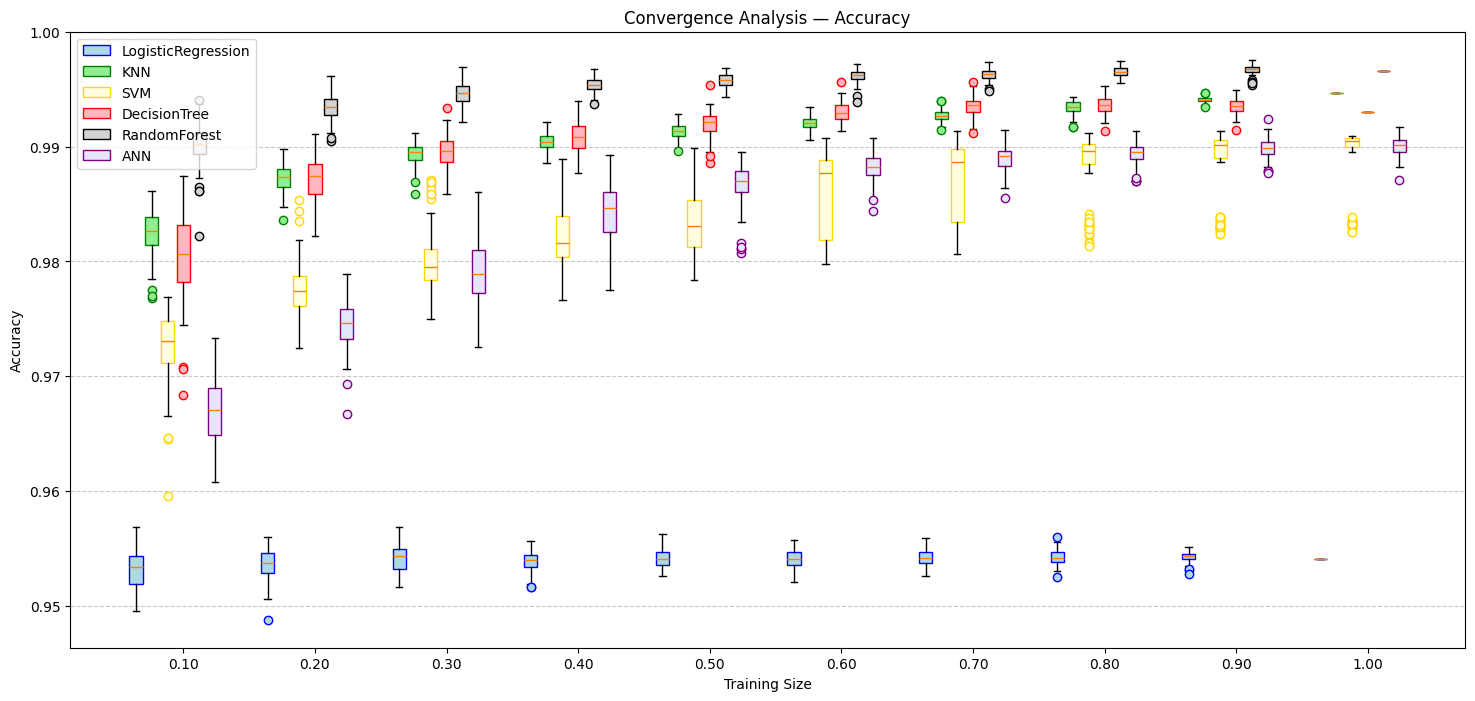

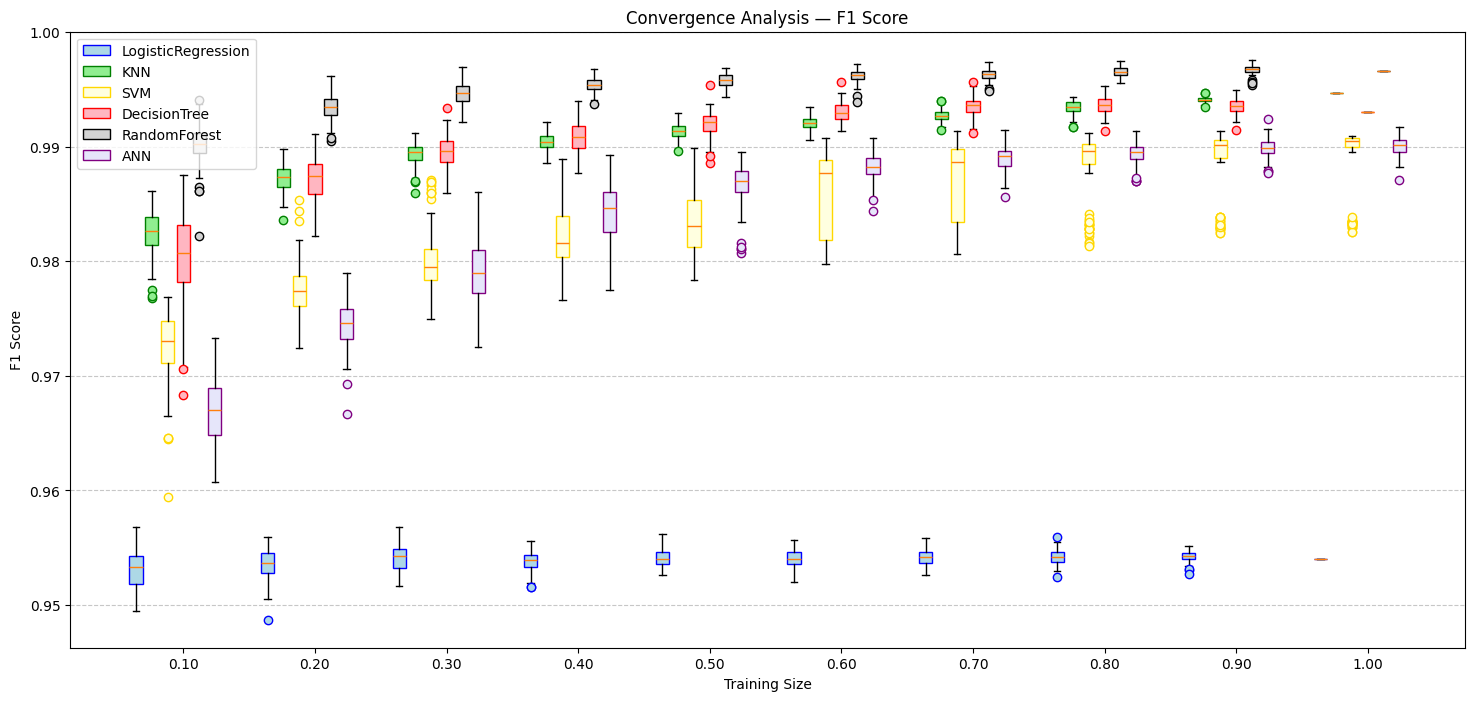

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

colors = {
    "LogisticRegression": ("lightblue", "blue"),
    "KNN": ("lightgreen", "green"),
    "SVM": ("lightyellow", "gold"),
    "DecisionTree": ("lightpink", "red"),
    "RandomForest": ("lightgray", "black"),
    "ANN": ("lavender", "purple")
}

# === ACCURACY ===
plt.figure(figsize=(18, 8))
positions = np.arange(len(training_sizes))

for i, m in enumerate(models):
    data = [results_accuracy[m][f"{s:.2f}"] for s in training_sizes]

    offset = (i - len(models)/2) * 0.12
    plt.boxplot(
        data,
        positions=positions + offset,
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=colors[m][0], color=colors[m][1]),
        flierprops=dict(markerfacecolor=colors[m][0], markeredgecolor=colors[m][1])
    )

legend_elements = [
    Rectangle((0,0),1,1,facecolor=colors[m][0],edgecolor=colors[m][1],label=m)
    for m in models
]

plt.legend(handles=legend_elements, loc="upper left")
plt.title("Convergence Analysis — Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.xticks(positions, [f"{s:.2f}" for s in training_sizes])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# === F1 SCORE ===
plt.figure(figsize=(18, 8))
positions = np.arange(len(training_sizes))

for i, m in enumerate(models):
    data = [results_f1[m][f"{s:.2f}"] for s in training_sizes]
    offset = (i - len(models)/2) * 0.12
    plt.boxplot(
        data,
        positions=positions + offset,
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=colors[m][0], color=colors[m][1]),
        flierprops=dict(markerfacecolor=colors[m][0], markeredgecolor=colors[m][1])
    )

legend_elements = [
    Rectangle((0,0),1,1,facecolor=colors[m][0],edgecolor=colors[m][1],label=m)
    for m in models
]

plt.legend(handles=legend_elements, loc="upper left")
plt.title("Convergence Analysis — F1 Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.xticks(positions, [f"{s:.2f}" for s in training_sizes])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Logistic Regression behaves differently from all the other models because it is the only strictly linear classifier in the comparison. Its decision boundary is simple and convex, so it reaches its optimal solution very quickly and shows almost no sensitivity to sampling variability. As a result, its boxplots remain flat and clearly separated from the non‑linear models.

In contrast, the other models (KNN, Decision Tree, Random Forest, ANN, and SVM with RBF kernel) are non‑linear and therefore more expressive and more sensitive to small changes in the training data. Among them, ANN and SVM retain a small amount of variance even at the largest training size:
– SVM (RBF) depends on the exact set of support vectors, which can shift slightly across iterations.
– ANN involves random weight initialization and stochastic optimization, leading to small fluctuations across runs.

This is why only ANN and SVM do not collapse into a perfect line at full training size, while Logistic Regression remains flat from the beginning.

Although accuracy and F1 produce visually similar convergence plots, this is not a limitation of the analysis but rather an indication that the dataset is balanced and the models behave consistently across metrics. The similarity confirms that no significant trade‑offs exist between precision and recall, and that the classification task is well‑posed. If the goal were to highlight more nuanced differences between models, metrics such as AUC, log‑loss, or calibration scores could provide additional insight.

In [ ]:
# BEGINNING OF THE ORIGINAL CONVERGENCE EXPERIMENT ACROSS ALL MODELS FOR THE MEAN‑DISTRIBUTION PLOT
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def run_model(model, model_name, X_train, y_train, X_test, y_test, training_sizes, iterations=500):
    print(f"\n=== Running model: {model_name} ===")

    accuracy_results = {size: [] for size in training_sizes}
    f1_results = {size: [] for size in training_sizes}

    for size in training_sizes:
        subset_len = int(size * len(X_train))

        for i in range(iterations):
            if i % 50 == 0:
                print(f"{model_name} - size {int(size*100)}% - iter {i}")

            idx = np.random.choice(len(X_train), subset_len, replace=False)
            X_sub = X_train[idx]
            y_sub = y_train[idx]

            model.fit(X_sub, y_sub)
            y_pred = model.predict(X_test)

            accuracy_results[size].append(accuracy_score(y_test, y_pred))
            f1_results[size].append(f1_score(y_test, y_pred))

        print(f"Completed size {int(size*100)}%")

    accuracy_mean = {size: np.mean(vals) for size, vals in accuracy_results.items()}
    f1_mean = {size: np.mean(vals) for size, vals in f1_results.items()}

    print(f"=== Completed model: {model_name} ===")
    return accuracy_mean, f1_mean


In [ ]:
training_sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

results_accuracy = {}
results_f1 = {}


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, solver='liblinear')

accuracy_logreg, f1_logreg = run_model(
    log_reg,
    "Logistic Regression",
    X_train, y_train,
    X_test, y_test,
    training_sizes
)

results_accuracy["Logistic Regression"] = accuracy_logreg
results_f1["Logistic Regression"] = f1_logreg



=== Running model: Logistic Regression ===
Logistic Regression - size 10% - iter 0
Logistic Regression - size 10% - iter 50
Logistic Regression - size 10% - iter 100
Logistic Regression - size 10% - iter 150
Logistic Regression - size 10% - iter 200
Logistic Regression - size 10% - iter 250
Logistic Regression - size 10% - iter 300
Logistic Regression - size 10% - iter 350
Logistic Regression - size 10% - iter 400
Logistic Regression - size 10% - iter 450
Completed size 10%
Logistic Regression - size 20% - iter 0
Logistic Regression - size 20% - iter 50
Logistic Regression - size 20% - iter 100
Logistic Regression - size 20% - iter 150
Logistic Regression - size 20% - iter 200
Logistic Regression - size 20% - iter 250
Logistic Regression - size 20% - iter 300
Logistic Regression - size 20% - iter 350
Logistic Regression - size 20% - iter 400
Logistic Regression - size 20% - iter 450
Completed size 20%
Logistic Regression - size 30% - iter 0
Logistic Regression - size 30% - iter 50
Log

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

accuracy_knn, f1_knn = run_model(
    knn, "k-NN",
    X_train, y_train,
    X_test, y_test,
    training_sizes,
    iterations=100
)

results_accuracy["k-NN"] = accuracy_knn
results_f1["k-NN"] = f1_knn



=== Running model: k-NN ===
k-NN - size 10% - iter 0
k-NN - size 10% - iter 50
Completed size 10%
k-NN - size 20% - iter 0
k-NN - size 20% - iter 50
Completed size 20%
k-NN - size 30% - iter 0
k-NN - size 30% - iter 50
Completed size 30%
k-NN - size 40% - iter 0
k-NN - size 40% - iter 50
Completed size 40%
k-NN - size 50% - iter 0
k-NN - size 50% - iter 50
Completed size 50%
k-NN - size 60% - iter 0
k-NN - size 60% - iter 50
Completed size 60%
k-NN - size 70% - iter 0
k-NN - size 70% - iter 50
Completed size 70%
k-NN - size 80% - iter 0
k-NN - size 80% - iter 50
Completed size 80%
k-NN - size 90% - iter 0
k-NN - size 90% - iter 50
Completed size 90%
k-NN - size 100% - iter 0
k-NN - size 100% - iter 50
Completed size 100%
=== Completed model: k-NN ===


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)

accuracy_svm, f1_svm = run_model(
    svm, "SVM",
    X_train, y_train,
    X_test, y_test,
    training_sizes,
    iterations=100
)

results_accuracy["SVM"] = accuracy_svm
results_f1["SVM"] = f1_svm



=== Running model: SVM ===
SVM - size 10% - iter 0
SVM - size 10% - iter 50
Completed size 10%
SVM - size 20% - iter 0
SVM - size 20% - iter 50
Completed size 20%
SVM - size 30% - iter 0
SVM - size 30% - iter 50
Completed size 30%
SVM - size 40% - iter 0
SVM - size 40% - iter 50
Completed size 40%
SVM - size 50% - iter 0
SVM - size 50% - iter 50
Completed size 50%
SVM - size 60% - iter 0
SVM - size 60% - iter 50
Completed size 60%
SVM - size 70% - iter 0
SVM - size 70% - iter 50
Completed size 70%
SVM - size 80% - iter 0
SVM - size 80% - iter 50
Completed size 80%
SVM - size 90% - iter 0
SVM - size 90% - iter 50
Completed size 90%
SVM - size 100% - iter 0
SVM - size 100% - iter 50
Completed size 100%
=== Completed model: SVM ===


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

accuracy_dt, f1_dt = run_model(
    dt, "Decision Tree",
    X_train, y_train,
    X_test, y_test,
    training_sizes,
    iterations=100
)

results_accuracy["Decision Tree"] = accuracy_dt
results_f1["Decision Tree"] = f1_dt



=== Running model: Decision Tree ===
Decision Tree - size 10% - iter 0
Decision Tree - size 10% - iter 50
Completed size 10%
Decision Tree - size 20% - iter 0
Decision Tree - size 20% - iter 50
Completed size 20%
Decision Tree - size 30% - iter 0
Decision Tree - size 30% - iter 50
Completed size 30%
Decision Tree - size 40% - iter 0
Decision Tree - size 40% - iter 50
Completed size 40%
Decision Tree - size 50% - iter 0
Decision Tree - size 50% - iter 50
Completed size 50%
Decision Tree - size 60% - iter 0
Decision Tree - size 60% - iter 50
Completed size 60%
Decision Tree - size 70% - iter 0
Decision Tree - size 70% - iter 50
Completed size 70%
Decision Tree - size 80% - iter 0
Decision Tree - size 80% - iter 50
Completed size 80%
Decision Tree - size 90% - iter 0
Decision Tree - size 90% - iter 50
Completed size 90%
Decision Tree - size 100% - iter 0
Decision Tree - size 100% - iter 50
Completed size 100%
=== Completed model: Decision Tree ===


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

accuracy_rf, f1_rf = run_model(
    rf, "Random Forest",
    X_train, y_train,
    X_test, y_test,
    training_sizes,
    iterations=100
)

results_accuracy["Random Forest"] = accuracy_rf
results_f1["Random Forest"] = f1_rf



=== Running model: Random Forest ===
Random Forest - size 10% - iter 0
Random Forest - size 10% - iter 50
Completed size 10%
Random Forest - size 20% - iter 0
Random Forest - size 20% - iter 50
Completed size 20%
Random Forest - size 30% - iter 0
Random Forest - size 30% - iter 50
Completed size 30%
Random Forest - size 40% - iter 0
Random Forest - size 40% - iter 50
Completed size 40%
Random Forest - size 50% - iter 0
Random Forest - size 50% - iter 50
Completed size 50%
Random Forest - size 60% - iter 0
Random Forest - size 60% - iter 50
Completed size 60%
Random Forest - size 70% - iter 0
Random Forest - size 70% - iter 50
Completed size 70%
Random Forest - size 80% - iter 0
Random Forest - size 80% - iter 50
Completed size 80%
Random Forest - size 90% - iter 0
Random Forest - size 90% - iter 50
Completed size 90%
Random Forest - size 100% - iter 0
Random Forest - size 100% - iter 50
Completed size 100%
=== Completed model: Random Forest ===


In [ ]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)

accuracy_ann, f1_ann = run_model(
    ann, "ANN",
    X_train, y_train,
    X_test, y_test,
    training_sizes,
    iterations=100
)

results_accuracy["ANN"] = accuracy_ann
results_f1["ANN"] = f1_ann



=== Running model: ANN ===
ANN - size 10% - iter 0
ANN - size 10% - iter 50
Completed size 10%
ANN - size 20% - iter 0
ANN - size 20% - iter 50
Completed size 20%
ANN - size 30% - iter 0
ANN - size 30% - iter 50
Completed size 30%
ANN - size 40% - iter 0
ANN - size 40% - iter 50
Completed size 40%
ANN - size 50% - iter 0
ANN - size 50% - iter 50
Completed size 50%
ANN - size 60% - iter 0
ANN - size 60% - iter 50
Completed size 60%
ANN - size 70% - iter 0
ANN - size 70% - iter 50
Completed size 70%
ANN - size 80% - iter 0
ANN - size 80% - iter 50
Completed size 80%
ANN - size 90% - iter 0
ANN - size 90% - iter 50
Completed size 90%
ANN - size 100% - iter 0
ANN - size 100% - iter 50
Completed size 100%
=== Completed model: ANN ===


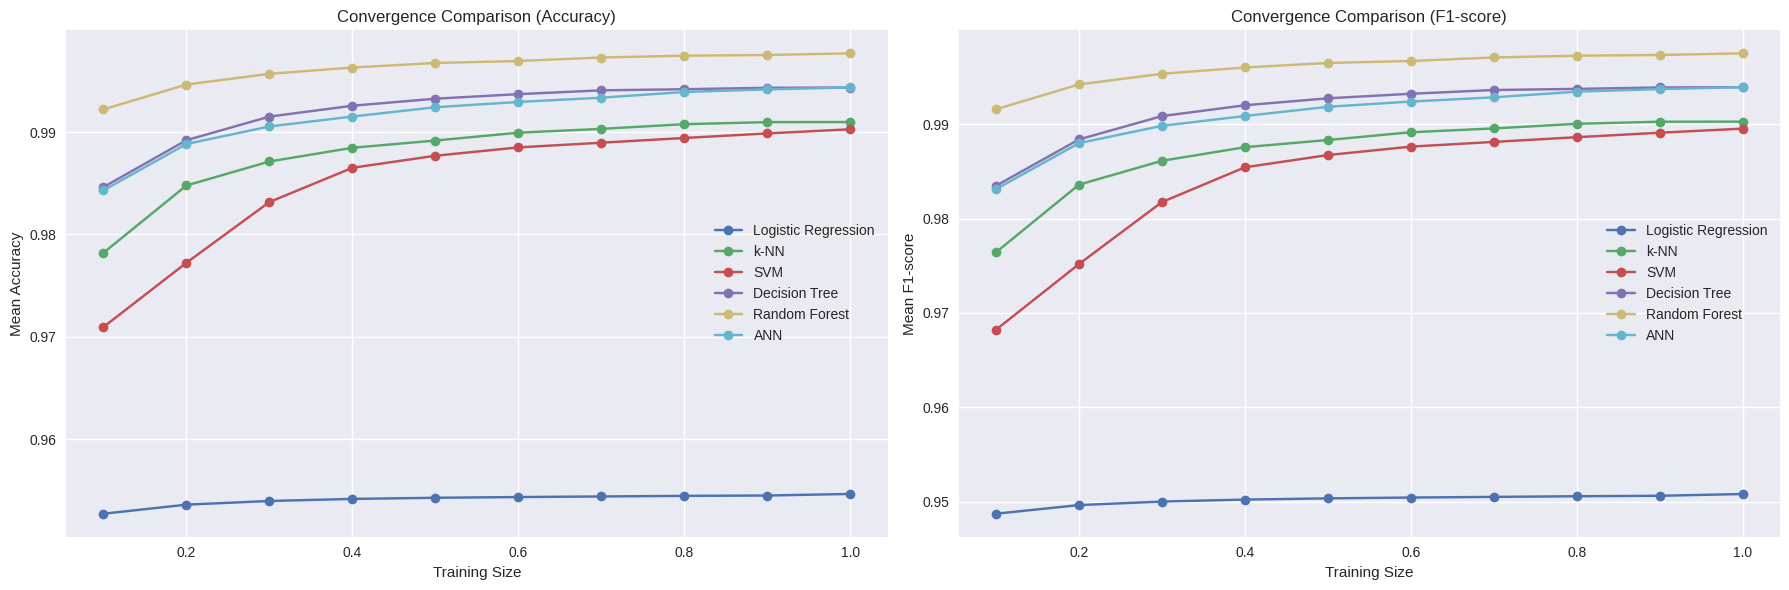

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# === 1. GRAFICO ACCURACY ===
ax = axes[0]

for model_name, acc_dict in results_accuracy.items():
    ax.plot(
        training_sizes,
        [acc_dict[size] for size in training_sizes],
        marker='o',
        label=model_name
    )

ax.set_title("Convergence Comparison (Accuracy)")
ax.set_xlabel("Training Size")
ax.set_ylabel("Mean Accuracy")
ax.grid(True)
ax.legend()

# === 2. GRAFICO F1-SCORE ===
ax = axes[1]

for model_name, f1_dict in results_f1.items():
    ax.plot(
        training_sizes,
        [f1_dict[size] for size in training_sizes],
        marker='o',
        label=model_name
    )

ax.set_title("Convergence Comparison (F1-score)")
ax.set_xlabel("Training Size")
ax.set_ylabel("Mean F1-score")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()
